## House Price Prediction using Machine learning: Linear Regression and K-Nearest-Neighbor models)

**Team: Anne Dudzik**

**Course:** CISD 43 – BIG DATA MODELING AND ANALYSIS (Spring, 2026)

### Problem Statement
* This project  is about working with a large dataset to make house price predictions. I will conduct two machine learning models to look at how house attributes affect price. House prices are determined by many factors. Some of these are difficult to quantify at a big data level. Factors may be subjective, such as curb appeal or neighborhood ambiance. Others may be quantifiable but not available. For instance, Zillow removed climate risk data from its property listings as of November 2025. However, existing housing data shows correlations that are useful as partial predictors of house prices.
    
    
    
* **Keywords:** House price prediction, Real estate, Housing data, Machine learning, Linear Regression, KNN
	

### Required packages

* I will import the following libraries: Numpy and Pandas for working with Dataframes, Matplotlib.pyplot and seaborn for statistics and visualizations, and mpl_toolkits and sklearn for machine learning.


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits
#for machine learning models:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

| Library / Module | Purpose |
|------------------|--------|
| pandas | Provides data structures and tools for loading, cleaning, manipulating, and analyzing tabular data such as CSV files. |
| numpy | Supports numerical operations and efficient array-based computations used in data analysis. |
| seaborn and matplotlib | Enables clear visualizations. |
| mpl_toolkits and sklearn | Support machine learning. |

### Methodology

1. I have a large housing dataset provided from CISD 43's curriculum with house prices and other attributes which may possibly correlate with house price. I will generate two machine learning models to attempt to predict a house's price if given the other attributes. By splitting the data I already have into training data and testing data, I can construe a model using the large body of training data, and then test it by running the model with the testing data. This method works since I know the actual results of the testing data. In order to not bias the model with the testing data, it is not included when training machine learning models.



2. Machine Learning Models employed: Linear Regression and k-Nearest-Neighbor (KNN)
 * Model 1: Linear Regression
    * Linear Regression is a supervised machine learning model that generates a predictive line by constructing a line representing the best fit of existing data. The model tests how well selected attributes predict the target variable. For this project, the target variable is House Price.
 
 * Model 2: KNN
    * KNN, or K-Nearest-Neighbor, is a machine learning model that predicts a value by considering the nearest values (the number of which is what determines k). In this project we use the GradientBoostingRegressor call method. The same attributes will be selected as in the Linear Regression model, and the target variable will remain House Price.
 

### Exploratory Data Analysis: Data viewing, data cleaning, and data visualizations

#### This House Price Prediction dataset contains housing data records that include House Price and other attributes. I will select attributes of interest to apply to my models.

The features contained in this dataset, in addition to House Price, are the number of bedrooms, the number of bathrooms, square feet of living space, square feet of the property lot, number of floors, waterfront status, view status, condition, grade, square feet above, square feet of basement, year built, year renovated, zipcode, latitude, longitude, and two additional variables, sqft_living15 and sqft_lot15 that I am not able to interpret and will not use.

#### Import and View the Data:

In [113]:
#import the data csv file (the dataset) and view the first few lines to check that it's the correct data
data = pd.read_csv("House Price data/house_data.csv")
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [114]:
#show general statistics of all of the dataset's numerical variables
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


#### Data cleaning: Check if there are any missing values

In [115]:
#Data Cleaning: Check for missing data values
data.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

As displayed above, there are no missing values.

#### Check the datatypes of the columns:

In [116]:
#print(data.dtypes) also will tell datatypes but has less information than data.info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

The datatypes of the variables I am selecting (bedrooms, bathrooms, and square feet of living space) are integers and floats, so I will be able to use them as numerical values--I do not need to change data types. This dataset has 21613 rows and 21 columns.

**Data Visualizations:**
I conduct several data visualizations, employing capabilities from the Matplotlib and Seaborn libraries

**Creating a Bar Chart of the Number of Bedrooms** This visualizes the relative prevalence of houses with number of bathroom options

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

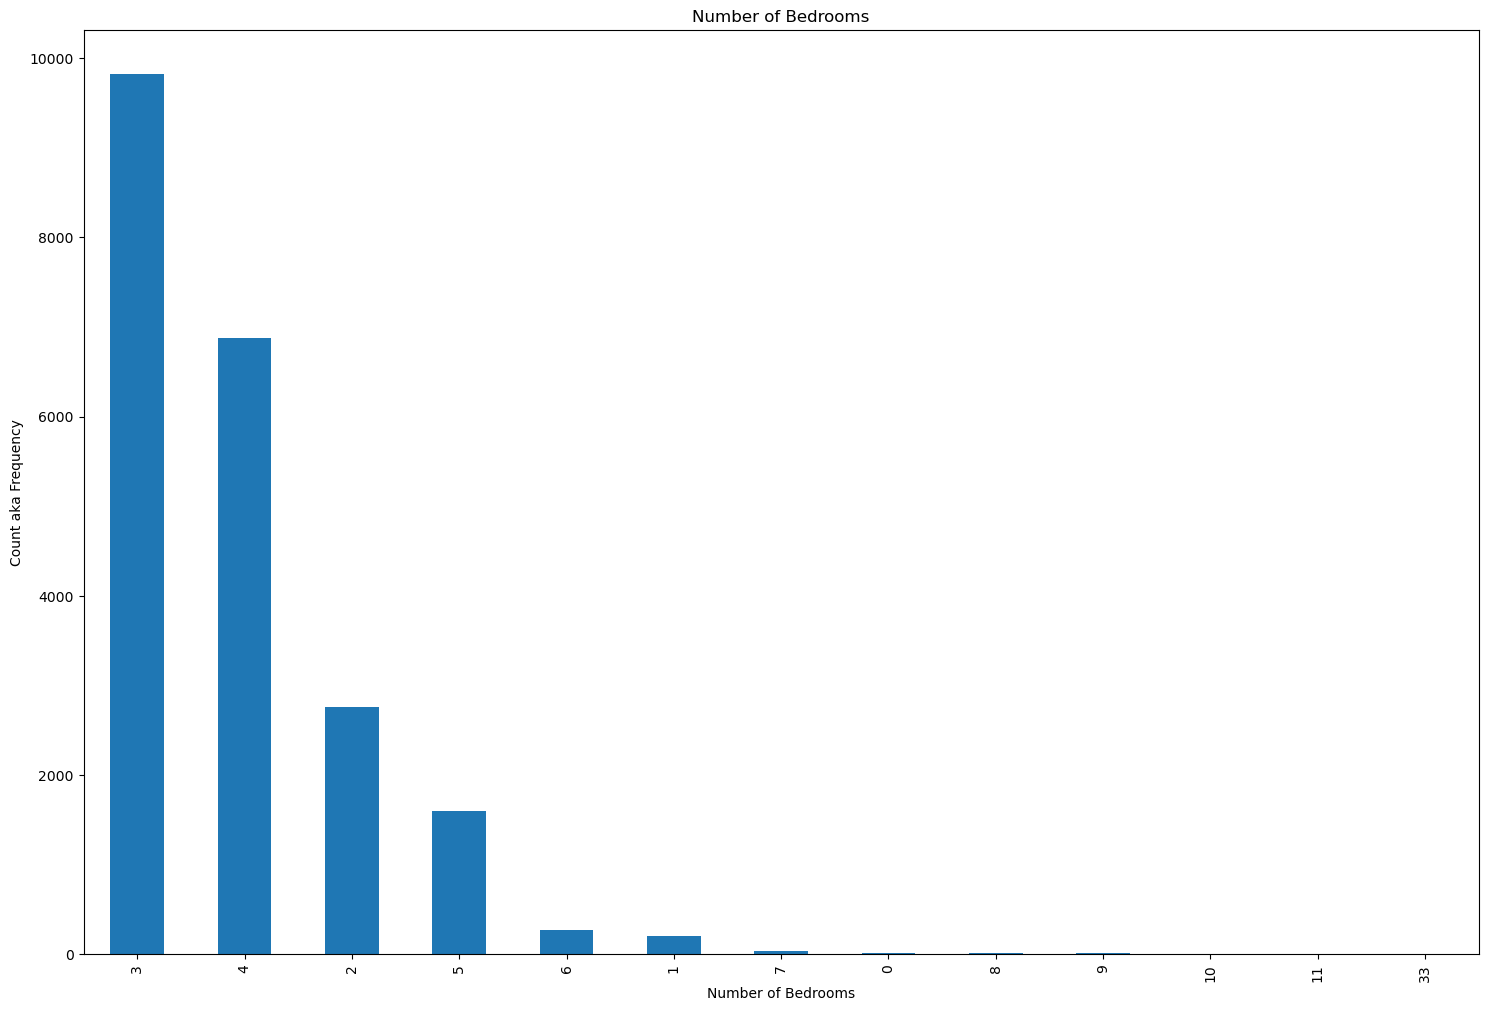

In [117]:
plt.figure(figsize=(18,12))
data['bedrooms'].value_counts().plot(kind='bar')
plt.title('Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count aka Frequency')
sns.despine

**Joint Plot**: A joint plot of the relationship between number of bedrooms and number of bathrooms. Note that the single entry with over 30 bedrooms is likely an error in data recording.

<Figure size 1800x1200 with 0 Axes>

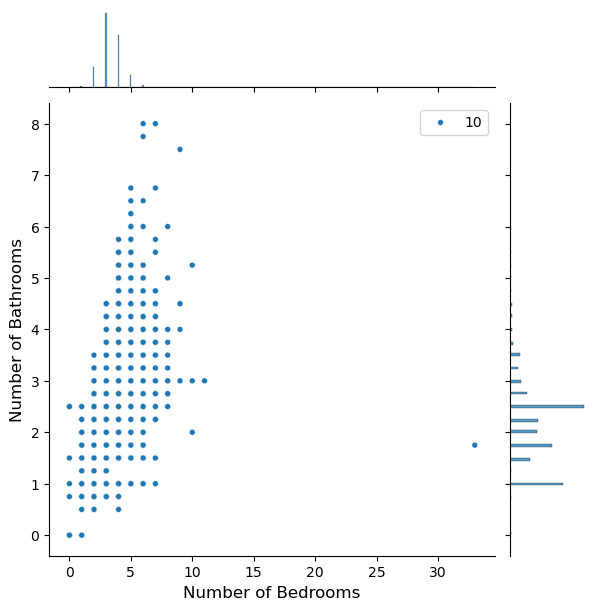

<function seaborn.utils.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=False, offset=None, trim=False)>

In [118]:
plt.figure(figsize=(18,12))
sns.jointplot(x=data.bedrooms.values, y=data.bathrooms.values, size=10)
plt.ylabel('Number of Bathrooms',fontsize=12)
plt.xlabel('Number of Bedrooms',fontsize=12)
plt.show()
sns.despine

**Scatter Plot:** A scatter plot of the relationship between price and number of bedrooms, price and square feet of living space, and price and number of floors

Text(0, 0.5, 'Price')

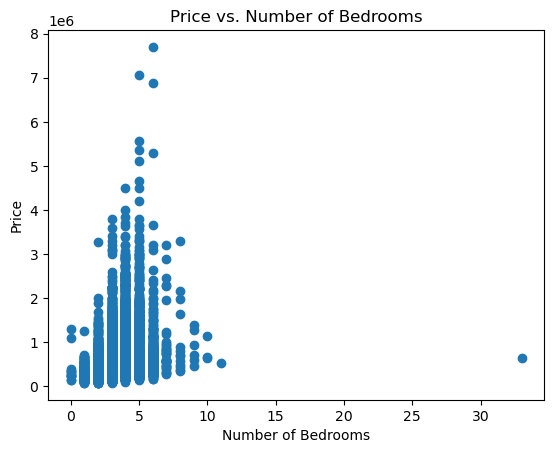

In [119]:
plt.scatter(data.bedrooms,data.price)
plt.title("Price vs. Number of Bedrooms")
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

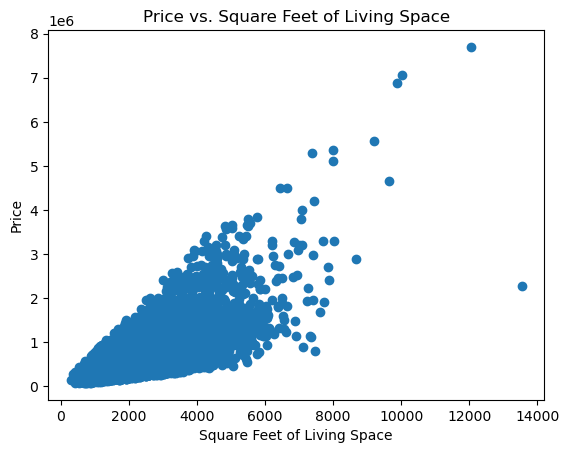

In [120]:
plt.scatter(data.sqft_living,data.price)
plt.title('Price vs. Square Feet of Living Space')
plt.xlabel('Square Feet of Living Space')
plt.ylabel('Price')

Text(0, 0.5, 'Price')

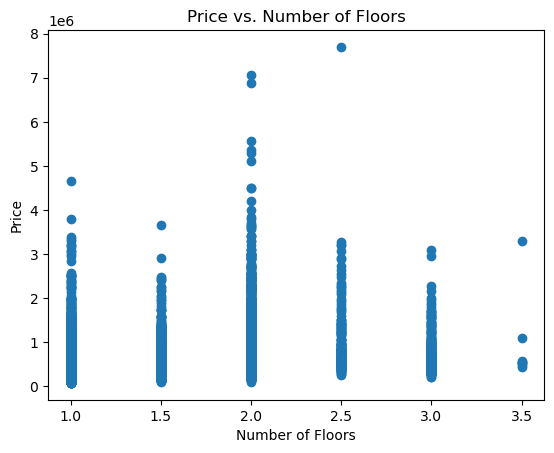

In [121]:
plt.scatter(data.floors,data.price)
plt.title('Price vs. Number of Floors')
plt.xlabel('Number of Floors')
plt.ylabel('Price')

### Machine Learning: Linear Regression on how well Price is predicted by number of bedrooms, number of bathrooms, and square feet of living space

In [122]:
#Prepare the feature matrix X and the target vector y
X = data[['bedrooms','bathrooms','sqft_living']]
y= data['price']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
#Create and train a linear regression machine learning model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
#### On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [124]:
#make predictions on the test set only
y_pred = model.predict(X_test)

In [125]:
#Evaluate the linear regression model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R square score: {r2}')

Mean Squared Error: 74237634953.18285
R square score: 0.50893471722649


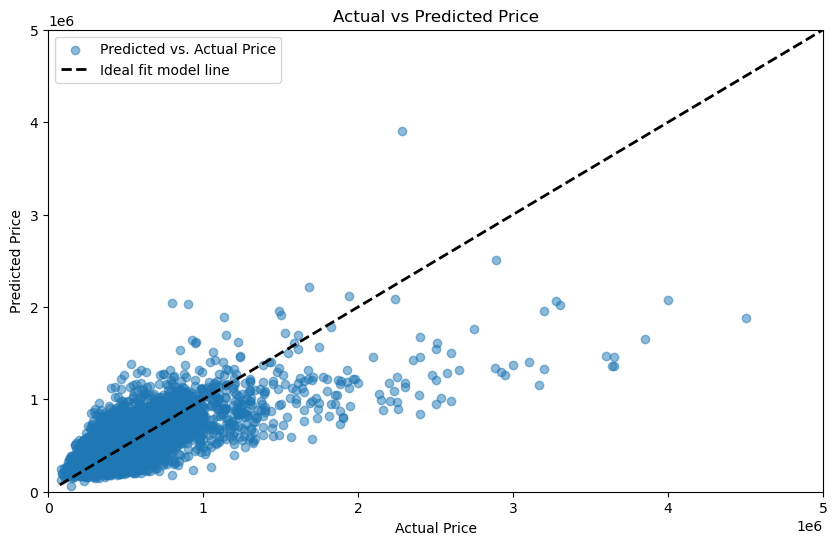

In [126]:
#Plot the resulting fit between the predicted price and the actual price
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predicted vs. Actual Price')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Ideal fit model line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.xlim(0, 5000000)
plt.ylim(0, 5000000)
plt.legend()
plt.show()

### Machine Learning Model 2: Predicting Price using the k-Nearest-Neighbor (KNN) model

In [127]:
# Select the features and the target variable
features = data[['bedrooms','bathrooms','sqft_living']]
target = data['price']

In [128]:
# Normalize the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [129]:
# Split the data and train the KNN model
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [130]:
# Predict on the test data
y_pred = knn.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R square score: {r2}')

Mean Squared Error: 82509811775.10803
R square score: 0.45421612533205613


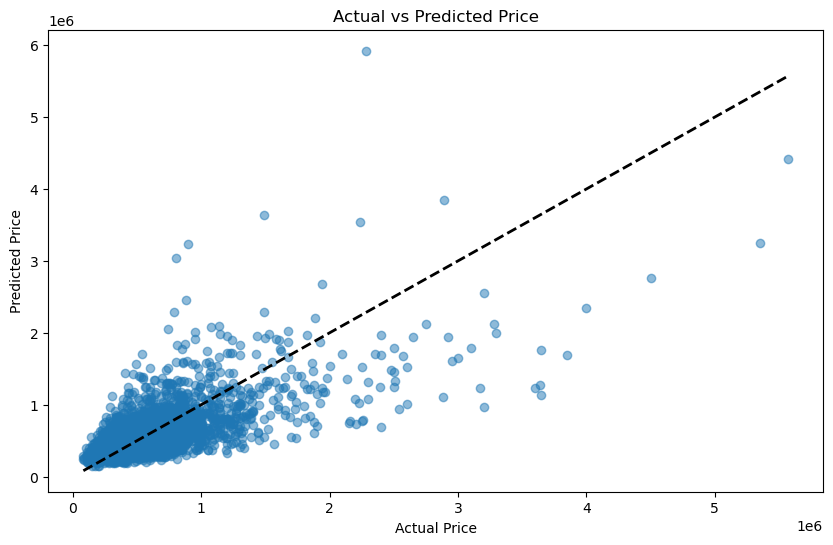

In [131]:

# Plot the results by creating a figure
plt.figure(figsize=(10,6))

#Create a scatter plot of Actual versus Predicted Prices
plt.scatter(y_test,y_pred, alpha=0.5)
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()], 'k--', lw=2, label='Ideal fit model line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')  
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

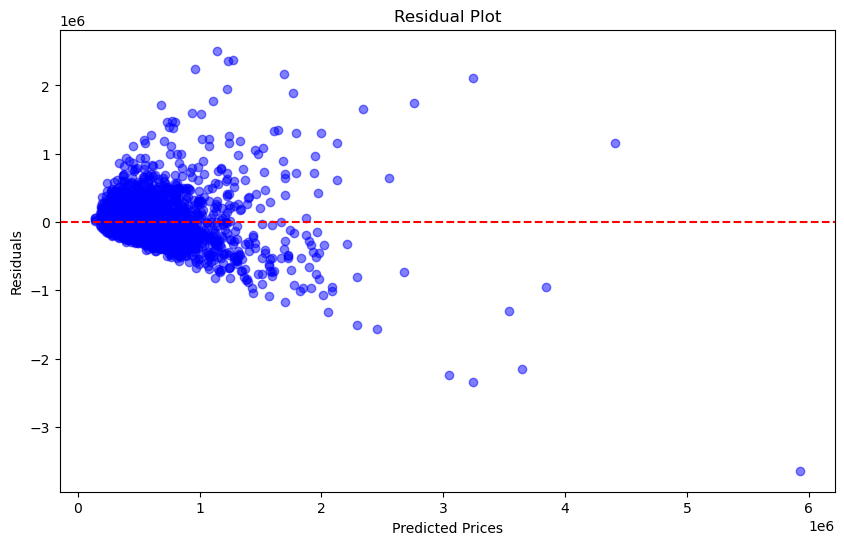

In [132]:
# Plot the residuals
residuals = y_test - y_pred
plt.figure(figsize=(10,6))
plt.scatter(y_pred,residuals,alpha=0.5,color='b')
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show

### Conclusions
   - For the Linear Regression model test
   - For the KNN model test
   - For the general dataset
	

For the Linear Regression model test:

This model employed Linear Regression to predict House Price based on the three variables of Number of Bedrooms, Number of Bathrooms, and Square Feet of Living Space. The mean squared error was found to be 74237634953.18285, and the R squared score was found to be 0.50893471722649. 
The R squared score of essentially .5 suggests the variables are a fairly strong but not extremely good predictor of house price. As expected, there are likely additional variables that could help the model. Also Price in the housing market has a high amount of leeway, since it is set partially based on subjective evaluation of likely demand.

For the KNN model test:

This model employed the k-Nearest-Neighbor machine learning method to predict House Price based on the same above predictor variables of Number of Bedrooms, Number of Bathrooms, and Square Feet of Living Space. The mean squared error was found to be 82509811775.10803 which is very slightly higher than the mean squared error of the Linear Regression model. Low mean squared errors show a better fit. 
The R squared score was found to be 0.45421612533205613. This value of essentially .45 is significantly lower than the R squared score of the Linear Regression model. Higher R squared values mean better found relationships between the prediction variables and the target variables.


For the general dataset and comparisons of models:

The Linear Regression model had a lower (therefore better) MSE, but the KNN model had a higher (therfore better) R squared score. I cannot definitively say which model is better.

Advantages of this dataset was that n was large, and there were no missing values. Additionally, the results were able to suggest a moderately strong predictive capability of each model. In summary, both models have utility as when trying to predict house price given the number of bedrooms, number of bathrooms, and the square feet of living space.

###  References
   - The course material (lectures, modules, labs, and provided Jupyter notebook examples) provided by Professor Angel Martinon Hernandez in his CISD 43 course at Mt. San Antonio College, Spring term 2026.
   
	

### Credits

- 
> *This code is based on and relies heavily on the code of Professor Angel Martinon Hernandez in his CISD 43 course at Mt. San Antonio College, Spring term 2026. It is the capstone project component of the course, and is uploaded here as a record of knowlege as I work toward doing environmental data work.*

In [133]:
# End of Project